In [12]:
# Predicción de Precios de Vivienda con Random Forest Regressor y Regresión Lineal
#https://www.kaggle.com/datasets/camnugent/california-housing-prices
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame



In [13]:
# Split features & target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize numeric variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Regresión Lineal

In [14]:
#Regresión Lineal

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
preds_lr = lin_reg.predict(X_test)


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, preds_lr)
rmse = np.sqrt(mean_squared_error(y_test, preds_lr))
r2 = r2_score(y_test, preds_lr)

print(f"Linear Regression Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


Linear Regression Results:
MAE:  0.527
RMSE: 0.728
R²:   0.596


In [18]:
results = []
results.append(["Linear Regression", mae, rmse, r2])
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print(results_df.sort_values(by="R²", ascending=False))


               Model       MAE      RMSE       R²
0  Linear Regression  0.527247  0.728401  0.59577


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Diferenets modelos en 1
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42),
    "Linear Regression": LinearRegression()
}


In [23]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, mae, rmse, r2])

results = []
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print(results_df)

               Model       MAE      RMSE        R²
0  Linear Regression  0.527247  0.728401  0.595770
1       RandomForest  0.346981  0.520303  0.793747
2       RandomForest  0.346981  0.520303  0.793747
3  Linear Regression  0.527247  0.728401  0.595770


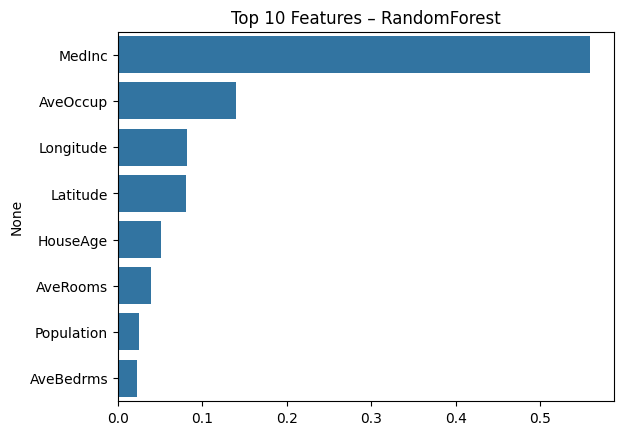

Linear Regression does not expose feature importances.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    try:
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=data.feature_names).sort_values(ascending=False)
        sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
        plt.title(f"Top 10 Features – {name}")
        plt.show()
    except AttributeError:
        print(f"{name} does not expose feature importances.")



**Error Absoluto Medio (MAE):**

*   **Cómo se calcula:** Imagina que tienes las predicciones de tu modelo y los valores reales. El MAE es el promedio de la diferencia (sin importar si es positiva o negativa, por eso se llama "absoluto") entre cada predicción y su valor real.
*   **Para qué sirve:** Te da una idea del error típico que comete tu modelo en promedio. Un número más bajo en el MAE significa que tu modelo se equivoca menos en promedio.

**Raíz del Error Cuadrático Medio (RMSE):**

*   **Cómo se calcula:** También compara las predicciones con los valores reales, pero primero eleva al cuadrado esas diferencias, luego saca el promedio de esos cuadrados, y finalmente le saca la raíz cuadrada.
*   **Para qué sirve:** Al elevar al cuadrado las diferencias, el RMSE le da más importancia a los errores grandes. Es decir, si tu modelo tiene algunos errores muy grandes, el RMSE será más alto que el MAE. Un RMSE más bajo también indica un mejor modelo.

**¿Qué se considera un "buen" número para MAE y RMSE?**

No hay un número mágico que sea bueno para todos los casos. Depende mucho de:

*   **De qué trata tu modelo:** Si estás prediciendo precios de casas (que pueden ser números grandes), un MAE o RMSE de 10,000 podría ser bueno. Si predices una puntuación del 1 al 5, un error de 10,000 sería terrible. Los números "buenos" son relativos a la escala de lo que estás prediciendo.
*   **Con qué lo comparas:** La mejor forma de saber si tus números son buenos es compararlos:
    *   **Con un modelo simple:** Compara tu modelo con uno muy básico (por ejemplo, uno que siempre prediga el promedio). Si tu modelo tiene MAE y RMSE mucho más bajos, ¡eso es bueno!
    *   **Con otros modelos:** Compara los resultados de diferentes modelos. El modelo con MAE y RMSE más bajos suele ser el mejor.
    *   **Con lo que esperas:** Si eres experto en el tema, puedes tener una idea de cuánto error es aceptable.

En resumen, busca los valores de MAE y RMSE más bajos posible. Pero para saber si son "buenos", compáralos con la escala de tus datos y con los resultados de otros modelos.